# fxhash — growth of the number of projects (images)

Analysis of the data collected by `fxhash_scraper.py` from the fxhash **v2** public GraphQL API.

The dataset covers **both versions** of the platform:
- **fxhash 1.0** — the original platform on **Tezos**
- **fxhash 2.0** — the newer EVM version on **Ethereum** and **Base**

Before running this notebook:
1. `pip install -r requirements.txt`
2. `python fxhash_scraper.py`  — creates `data/fxhash_tokens.csv`

Then run the cells below top to bottom (or **Kernel → Restart & Run All**).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

df = pd.read_csv('data/fxhash_tokens.csv')

df['mint_opens_at'] = pd.to_datetime(df['mint_opens_at'], utc=True, errors='coerce')
df = df.dropna(subset=['mint_opens_at']).sort_values('mint_opens_at').reset_index(drop=True)

df['version'] = df['chain'].map(lambda c: 'fxhash 1.0 (Tezos)' if c == 'TEZOS'
                                else 'fxhash 2.0 (EVM)')

print(f'Total projects: {len(df)}')
print('Period:', df['mint_opens_at'].min().date(), '->', df['mint_opens_at'].max().date())
df.head()

Total projects: 28194
Period: 2021-11-03 -> 2026-08-14


,id,name,version,chain,author_name,author_id,created_at,mint_opens_at,supply,iterations_count
0,0,FXHASH Generative Logo,fxhash 1.0 (Tezos),TEZOS,fxhash,tz1fepn7jZsCYBqCDhpM63hzh9g2Ytqk4Tpv,2021-11-03T12:26:02+00:00,2021-11-03 12:26:02+00:00,1000,1000.0
1,1,FXHASH Logo with Features,fxhash 1.0 (Tezos),TEZOS,fxhash,tz1fepn7jZsCYBqCDhpM63hzh9g2Ytqk4Tpv,2021-11-06T17:52:58+00:00,2021-11-06 17:52:58+00:00,1000,1000.0
2,2,RGB Elementary Cellular Automaton,fxhash 1.0 (Tezos),TEZOS,ciphrd,tz1PoDdN2oyRyF6DA73zTWAWYhNL4UGr3Egj,2021-11-07T20:47:26+00:00,2021-11-07 20:47:26+00:00,1000,1000.0
3,3,Punevyr's face,fxhash 1.0 (Tezos),TEZOS,punevyr,tz1SawhUHXWjiGK8gPK6QPmn95G8PkkSjA3S,2021-11-08T01:13:46+00:00,2021-11-08 01:13:46+00:00,100,100.0
4,4,Blobby,fxhash 1.0 (Tezos),TEZOS,Sam Tsao,tz1WZuFdbESHfBSvoBeao1Wkt7NCyUuXAT9D,2021-11-10T20:00:38+00:00,2021-11-10 20:00:38+00:00,512,512.0


In [2]:
print('By chain:')
print(df['chain'].value_counts().to_string())
print('\nBy version:')
print(df['version'].value_counts().to_string())

def cumulative_series(frame):
    """Running total of projects over time."""
    return frame.set_index('mint_opens_at').assign(c=1)['c'].sort_index().cumsum()

def monthly_series(frame):
    """Number of new projects per month."""
    return frame.set_index('mint_opens_at').assign(c=1)['c'].resample('MS').sum()

def style_date_axis(ax, interval_months):
    """Readable date ticks: spaced out, formatted, rotated and right-aligned."""
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval_months))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

tezos = df[df['chain'] == 'TEZOS']
evm = df[df['chain'] != 'TEZOS']

By chain:
chain
TEZOS       27430
BASE          643
ETHEREUM      121

By version:
version
fxhash 1.0 (Tezos)    27430
fxhash 2.0 (EVM)        764


## Chart 1 (combined) — both versions on one plot

Cumulative number of projects for each version. fxhash 2.0 (EVM) is far smaller
than fxhash 1.0 (Tezos), so it is drawn on its **own right-hand axis** to stay
readable — each curve has its own scale.

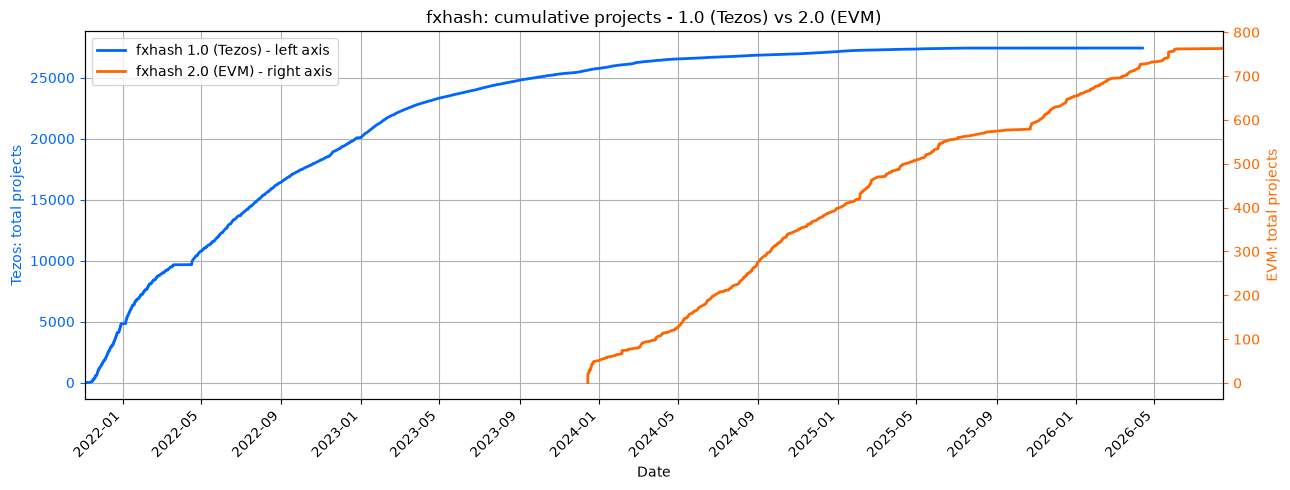

In [3]:
tz_cum = cumulative_series(tezos)
evm_cum = cumulative_series(evm)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(tz_cum.index, tz_cum.values, color='#0066ff', linewidth=2,
               label='fxhash 1.0 (Tezos) - left axis')
l2, = ax2.plot(evm_cum.index, evm_cum.values, color='#ff6600', linewidth=2,
               label='fxhash 2.0 (EVM) - right axis')

ax1.set_ylabel('Tezos: total projects', color='#0066ff')
ax2.set_ylabel('EVM: total projects', color='#ff6600')
ax1.tick_params(axis='y', colors='#0066ff')
ax2.tick_params(axis='y', colors='#ff6600')
ax1.set_xlabel('Date')
ax1.set_title('fxhash: cumulative projects - 1.0 (Tezos) vs 2.0 (EVM)')

ax1.set_xlim(df['mint_opens_at'].min(), df['mint_opens_at'].max())
style_date_axis(ax1, interval_months=4)
ax2.grid(False)
ax1.legend(handles=[l1, l2], loc='upper left')
plt.tight_layout()
plt.show()

## Chart 2 (separate) — fxhash 1.0 (Tezos, the old version)

Cumulative growth and new projects per month.

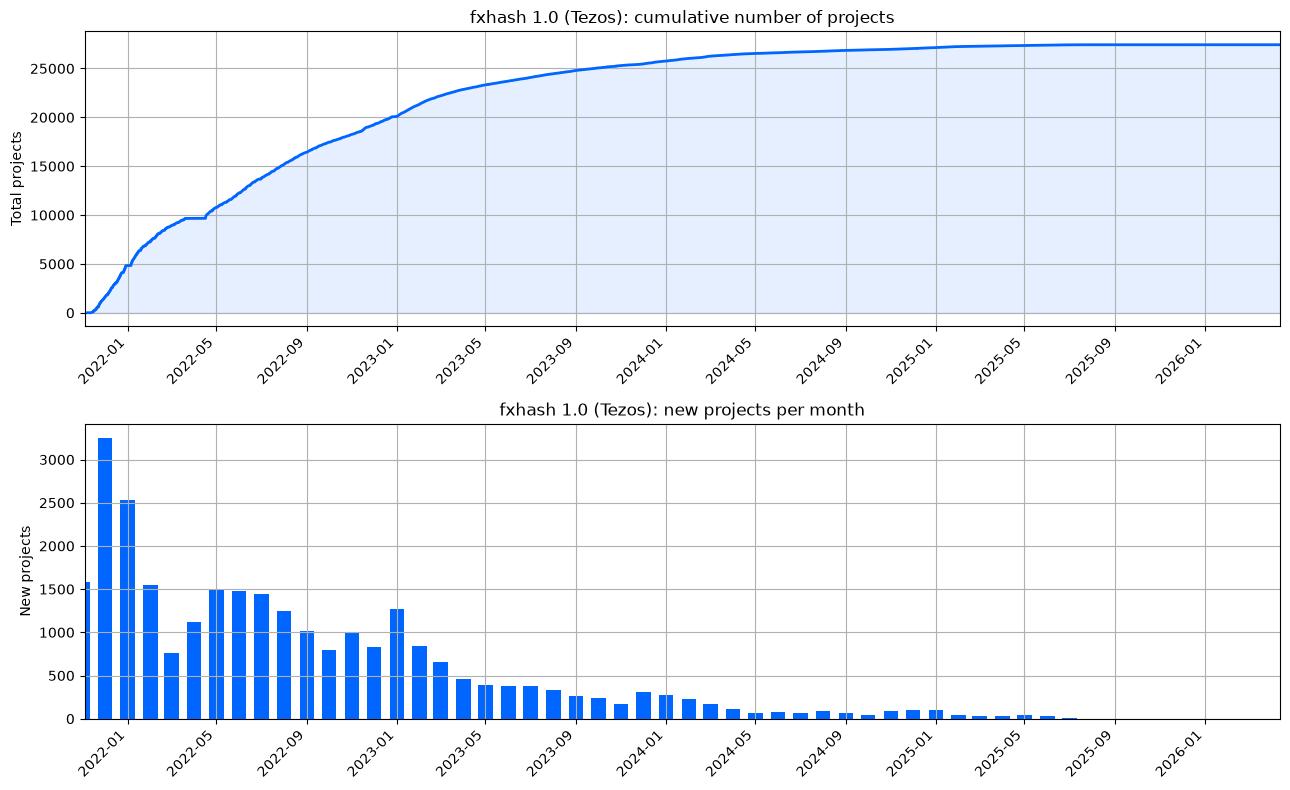

In [4]:
cum = cumulative_series(tezos)
mon = monthly_series(tezos)

fig, (axa, axb) = plt.subplots(2, 1, figsize=(13, 8))

axa.plot(cum.index, cum.values, color='#0066ff', linewidth=2)
axa.fill_between(cum.index, cum.values, alpha=0.1, color='#0066ff')
axa.set_title('fxhash 1.0 (Tezos): cumulative number of projects')
axa.set_ylabel('Total projects')

axb.bar(mon.index, mon.values, width=20, color='#0066ff')
axb.set_title('fxhash 1.0 (Tezos): new projects per month')
axb.set_ylabel('New projects')

for ax in (axa, axb):
    ax.set_xlim(tezos['mint_opens_at'].min(), tezos['mint_opens_at'].max())
    style_date_axis(ax, interval_months=4)
plt.tight_layout()
plt.show()

## Chart 3 (separate) — fxhash 2.0 (Ethereum + Base, the new version)

Cumulative growth, plus new projects per month split by chain (Ethereum vs Base).

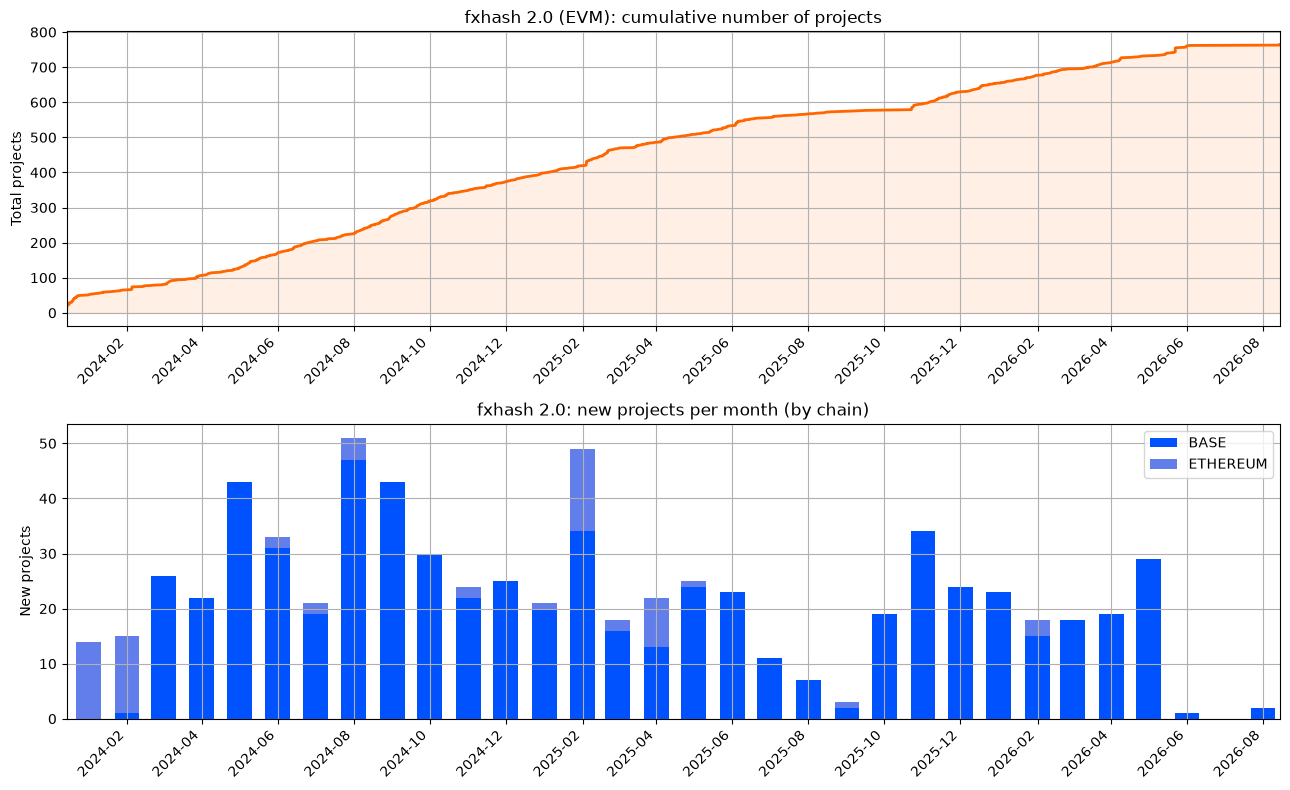

In [5]:
cum = cumulative_series(evm)

mon_by_chain = (evm.set_index('mint_opens_at').assign(c=1)
                .groupby('chain')['c'].resample('MS').sum()
                .unstack('chain').fillna(0))

fig, (axa, axb) = plt.subplots(2, 1, figsize=(13, 8))

axa.plot(cum.index, cum.values, color='#ff6600', linewidth=2)
axa.fill_between(cum.index, cum.values, alpha=0.1, color='#ff6600')
axa.set_title('fxhash 2.0 (EVM): cumulative number of projects')
axa.set_ylabel('Total projects')

bottom = None
colors = {'ETHEREUM': '#627eea', 'BASE': '#0052ff'}
for chain in mon_by_chain.columns:
    vals = mon_by_chain[chain].values
    axb.bar(mon_by_chain.index, vals, width=20, bottom=bottom,
            label=chain, color=colors.get(chain))
    bottom = vals if bottom is None else bottom + vals
axb.set_title('fxhash 2.0: new projects per month (by chain)')
axb.set_ylabel('New projects')
axb.legend()

for ax in (axa, axb):
    ax.set_xlim(evm['mint_opens_at'].min(), evm['mint_opens_at'].max())
    style_date_axis(ax, interval_months=2)
plt.tight_layout()
plt.show()

## Summary — new projects per year and version

In [6]:
summary = (df.assign(year=df['mint_opens_at'].dt.year)
           .pivot_table(index='year', columns='version', values='id',
                        aggfunc='count', fill_value=0))
summary['Total'] = summary.sum(axis=1)
summary

version,fxhash 1.0 (Tezos),fxhash 2.0 (EVM),Total
year,,,
2021,4829,0,4829
2022,15257,0,15257
2023,5678,51,5729
2024,1376,347,1723
2025,289,256,545
2026,1,110,111
